<a href="https://colab.research.google.com/github/Moquiuti/fundamentos-ia-investigando-algoritmos-abordagens-machine-learning/blob/main/treinando_um_agente_com_Q_Learning_no_FrozenLake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium

In [2]:
import numpy as np
import gymnasium as gym
import random

In [3]:
# Criando o ambiente
env = gym.make("FrozenLake-v1", is_slippery=True)

In [4]:
# Número de estados e ações
num_states = env.observation_space.n
num_actions = env.action_space.n

# Inicializando a Q-table com zeros
q_table = np.zeros((num_states, num_actions))

# Hiperparâmetros
alpha = 0.8      # taxa de aprendizado
gamma = 0.95     # fator de desconto
epsilon = 1.0    # taxa inicial de exploração
epsilon_min = 0.01
epsilon_decay = 0.995

num_episodes = 2000
max_steps = 100

In [5]:
recompensas_por_episodio = []

for episodio in range(num_episodes):
    state, _ = env.reset()
    done = False
    recompensa_total = 0

    for passo in range(max_steps):
        # Política epsilon-greedy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Atualização da Q-table
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        recompensa_total += reward

        if done:
            break

    # Redução gradual da exploração
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    recompensas_por_episodio.append(recompensa_total)

In [6]:
print("Q-table aprendida:")
print(q_table)

Q-table aprendida:
[[2.00926514e-01 1.82108679e-01 3.93724683e-02 5.36405137e-02]
 [1.41281116e-02 1.95300528e-02 1.42485888e-02 2.11601762e-01]
 [3.24640402e-03 1.18146255e-02 7.81147716e-03 9.17581192e-02]
 [3.67069410e-03 4.70856957e-03 3.73900919e-03 4.84788652e-02]
 [2.61492283e-01 2.42701640e-03 1.75655409e-02 3.97626616e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [7.20561474e-02 1.22978684e-05 4.56269103e-07 2.80373381e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.45738573e-04 1.80839406e-02 5.39425273e-03 4.69575352e-01]
 [2.13410842e-02 6.11902992e-01 1.07303479e-03 1.27067666e-02]
 [2.08816955e-01 7.18232035e-02 1.77447113e-04 8.23073863e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.14355764e-02 2.36209071e-02 8.47799499e-01 7.20573346e-02]
 [1.16584326e-01 9.90131435e-01 8.47669074e-02 2.91869975e-01]
 [0.00000000e+00 0.00000000e+00 0.00

In [7]:
num_testes = 100
sucessos = 0

for episodio in range(num_testes):
    state, _ = env.reset()
    done = False

    for passo in range(max_steps):
        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state

        if done:
            sucessos += reward
            break

print(f"Sucessos em {num_testes} episódios de teste: {int(sucessos)}")
print(f"Taxa de sucesso: {sucessos / num_testes:.2%}")

Sucessos em 100 episódios de teste: 67
Taxa de sucesso: 67.00%


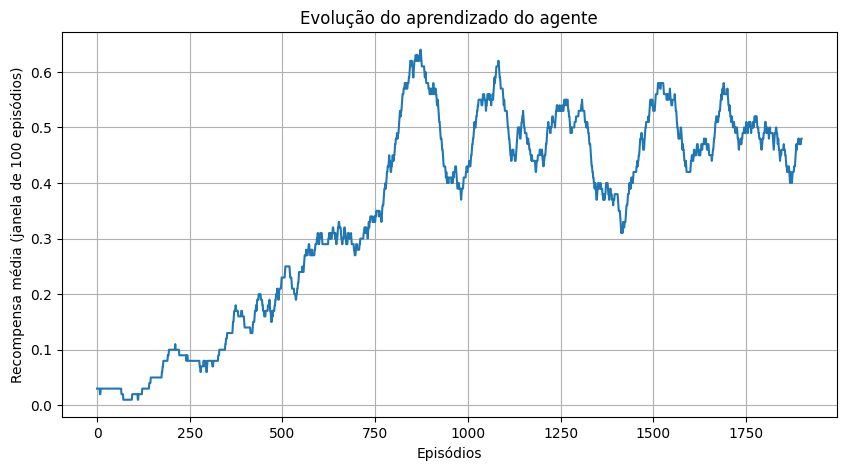

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(np.convolve(recompensas_por_episodio, np.ones(100)/100, mode='valid'))
plt.title("Evolução do aprendizado do agente")
plt.xlabel("Episódios")
plt.ylabel("Recompensa média (janela de 100 episódios)")
plt.grid(True)
plt.show()